In [1]:
import os
while "src" not in os.listdir():
    os.chdir("..")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from src.reading_in import read_in_proteins

In [2]:
TARGET_SYSTEMATIC="YMR231W"
TARGET_STANDARD="pep5"

# check that pep5 (YMR231W) is in our network
- is it part of the largest cc?

In [3]:
G0 = read_in_proteins("data/raw/protein.links.v12.0.txt.gz")
if TARGET_SYSTEMATIC in G0:
    print(f"{TARGET_STANDARD} is in our netowrk!")

largest_cc = max(nx.connected_components(G0))
if TARGET_SYSTEMATIC in largest_cc:
    print(f"{TARGET_STANDARD} is a node in the largest cc.")

pep5 is in our netowrk!
pep5 is a node in the largest cc.


What else can we say about our protein?
- how many nearst neighbours?

In [17]:
df = pd.read_csv("data/raw/interesting_proteins.csv")
names = np.array(df['systematic name'])

pep5 has 22 nearest neighbours


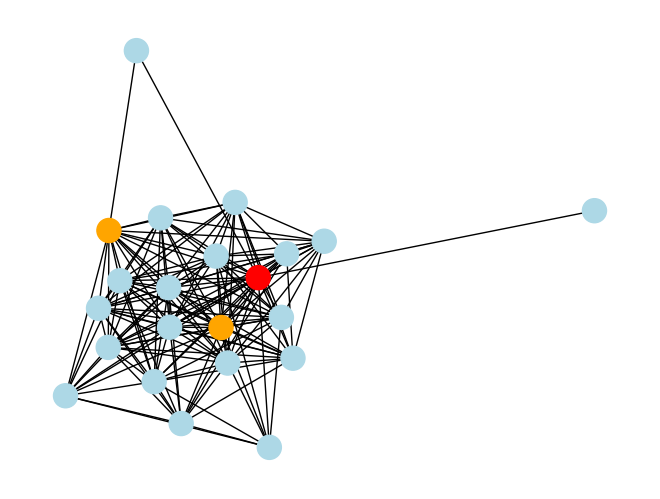

In [24]:
pep5_neighbourhood = G0.subgraph(list(G0.neighbors(TARGET_SYSTEMATIC)) + [TARGET_SYSTEMATIC])

node_colors = [
    'red' if n == TARGET_SYSTEMATIC 
    else 'orange' if n in names 
    else 'lightblue' for n in pep5_neighbourhood.nodes()
]

nx.draw(pep5_neighbourhood, with_labels=False, node_color=node_colors)

print(f"{TARGET_STANDARD} has {len(pep5_neighbourhood)} nearest neighbours")